In [4]:
import numpy as np
import skimage
import torch
import torchvision
import matplotlib.pyplot as plt
import torchxrayvision as xrv
import os
import glob
import random
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
from medigan import Generators
generators = Generators()

model = xrv.baseline_models.chestx_det.PSPNet()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/pspnet_chestxray_best_model_4.pth -O /Users/edrictam/.torchxrayvision/models_data/pspnet_chestxray_best_model_4.pth`
[██████████████████████████████████████████████████]


In [ ]:
#!/usr/bin/env python3
## the code below is for downloading the chest x-ray dataset...no need to run it again if you already have the dataset
## note the dataset is > 40 GB, so be patient
# Download the 56 zip files in Images_png in batches
# import urllib.request

# # URLs for the zip files
# links = [
#     'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
#     'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz',
#     'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz',
# 	'https://nihcc.box.com/shared/static/0aowwzs5lhjrceb3qp67ahp0rd1l1etg.gz',
#     'https://nihcc.box.com/shared/static/v5e3goj22zr6h8tzualxfsqlqaygfbsn.gz',
# 	'https://nihcc.box.com/shared/static/asi7ikud9jwnkrnkj99jnpfkjdes7l6l.gz',
# 	'https://nihcc.box.com/shared/static/jn1b4mw4n6lnh74ovmcjb8y48h8xj07n.gz',
#     'https://nihcc.box.com/shared/static/tvpxmn7qyrgl0w8wfh9kqfjskv6nmm1j.gz',
# 	'https://nihcc.box.com/shared/static/upyy3ml7qdumlgk2rfcvlb9k6gvqq2pj.gz',
# 	'https://nihcc.box.com/shared/static/l6nilvfa9cg3s28tqv1qc1olm3gnz54p.gz',
# 	'https://nihcc.box.com/shared/static/hhq8fkdgvcari67vfhs7ppg2w6ni4jze.gz',
# 	'https://nihcc.box.com/shared/static/ioqwiy20ihqwyr8pf4c24eazhh281pbu.gz'
# ]

# for idx, link in enumerate(links):
#     fn = 'images_%02d.tar.gz' % (idx+1)
#     print('downloading'+fn+'...')
#     urllib.request.urlretrieve(link, fn)  # download the zip file

# print("Download complete. Please check the checksums")

In [ ]:
## Note the code below is for extracting the zip files into a single folder...no need to run it again if you already have the dataset in place
# import os
# import tarfile

# # Destination folder for all images
# output_folder = 'all_images'
# os.makedirs(output_folder, exist_ok=True)

# # Extract images_01.tar.gz through images_12.tar.gz
# for i in range(1, 13):
#     tar_filename = f'images_{i:02d}.tar.gz'
#     if not os.path.exists(tar_filename):
#         print(f"{tar_filename} does not exist, skipping.")
#         continue
#     with tarfile.open(tar_filename, 'r:gz') as tar:
#         for member in tar.getmembers():
#             if member.isfile():
#                 original_name = os.path.basename(member.name)
#                 member.name = original_name
#                 target_path = os.path.join(output_folder, member.name)
#                 # Optionally avoid overwriting existing files
#                 if os.path.exists(target_path):
#                     base, ext = os.path.splitext(original_name)
#                     idx = 1
#                     # Find next available name
#                     while os.path.exists(os.path.join(output_folder, f"{base}_{idx}{ext}")):
#                         idx += 1
#                     member.name = f"{base}_{idx}{ext}"
#                 tar.extract(member, path=output_folder)
#     print(f"Extracted {tar_filename} into {output_folder}.")

# print(f"All specified archives are extracted into '{output_folder}'.")



In [4]:
# Set n = 1000
n = 100

# Load n random real images from all_images directory
all_images_dir = 'all_images'
image_files = glob.glob(os.path.join(all_images_dir, '*.png'))
random.shuffle(image_files)
selected_real_files = image_files[:n]

real_images_np = []
for img_path in selected_real_files:
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img).astype(np.float32)
    real_images_np.append(img_array)

real_images_np = np.array(real_images_np)
print(f"Loaded {len(real_images_np)} real images. Shape: {real_images_np.shape}")

# Generate n fake images using the generator
# Generate images in batches to avoid memory issues
batch_size = 1000
fake_images_list = []
output_base = 'output/00020_PGGAN_CHEST_XRAY'
os.makedirs(output_base, exist_ok=True)

for i in range(0, n, batch_size):
    current_batch_size = min(batch_size, n - i)
    print(f"Generating batch {i//batch_size + 1}/{(n-1)//batch_size + 1} ({current_batch_size} images)...")
    
    # Generate images - this will save them to output directory
    generators.generate(model_id=20, num_samples=current_batch_size, install_dependencies=False, output_path=output_base)


generated_files = sorted(glob.glob(os.path.join(output_base, '*.png')))
for img_path in generated_files:
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img).astype(np.float32) 
    fake_images_list.append(img_array)


fake_images_np = np.array(fake_images_list)
print(f"Generated {len(fake_images_np)} fake images. Shape: {fake_images_np.shape}")


Loaded 100 real images. Shape: (100, 1024, 1024, 3)
Generating batch 1/1 (100 images)...


100%|██████████| 4/4 [01:05<00:00, 16.34s/it]


Generated 100 fake images. Shape: (100, 1024, 1024, 3)


In [15]:
def extract_chest_xray_features(pred, model_targets, img_shape=None):
    """
    Extract sizes of all anatomical features and compute clinical ratios.
    
    Parameters:
    -----------
    pred : numpy array or torch tensor
        Prediction masks of shape (batch, num_features, H, W) or (num_features, H, W)
    model_targets : list
        List of feature names corresponding to the prediction masks
    img_shape : tuple, optional
        Original image shape (H, W) for calculating ratios. If None, uses pred shape.
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'feature_sizes': dict with normalized sizes (proportion of total image) for each feature
        - 'left_right_lung_ratio': ratio of left lung size to right lung size
        - 'ctr': Cardiothoracic Ratio (heart width / chest width)
    """
    # Convert to numpy if needed
    if torch.is_tensor(pred):
        pred = pred.cpu().numpy()
    
    # Handle batch dimension
    if len(pred.shape) == 4:
        pred = pred[0]  # Take first batch item
    
    # Ensure binary masks (threshold at 0.5 if needed)
    masks = (pred > 0.5).astype(np.float32)
    
    # Get image dimensions
    if img_shape is None:
        H, W = masks.shape[1], masks.shape[2]
    else:
        H, W = img_shape
    
    # Total number of pixels for normalization
    total_pixels = H * W
    
    # Extract sizes (normalized by total pixels) for each feature
    feature_sizes = {}
    for i, target in enumerate(model_targets):
        mask = masks[i]
        size_pixels = np.sum(mask)  # Total area in pixels
        size_normalized = size_pixels / total_pixels  # Normalized proportion
        feature_sizes[target] = float(size_normalized)
    
    # Calculate Left/Right Lung Ratio
    left_lung_size = feature_sizes.get('Left Lung', 0)
    right_lung_size = feature_sizes.get('Right Lung', 0)
    if right_lung_size > 0:
        left_right_lung_ratio = left_lung_size / right_lung_size
    else:
        left_right_lung_ratio = np.nan
    
    # Calculate CTR (Cardiothoracic Ratio): heart width / chest width
    heart_mask = masks[model_targets.index('Heart')] if 'Heart' in model_targets else None
    if heart_mask is not None and np.sum(heart_mask) > 0:
        # Find heart horizontal extent
        heart_rows = np.where(np.any(heart_mask, axis=1))[0]
        if len(heart_rows) > 0:
            # Use middle section of heart for width measurement
            mid_heart_row = heart_rows[len(heart_rows) // 2]
            heart_cols = np.where(heart_mask[mid_heart_row, :])[0]
            if len(heart_cols) > 0:
                heart_width = len(heart_cols)
            else:
                heart_width = 0
        else:
            heart_width = 0
        
        # Use full image width as chest width
        chest_width = W
        ctr = heart_width / chest_width if chest_width > 0 else np.nan
    else:
        ctr = np.nan
    
    return {
        'feature_sizes': feature_sizes,
        'left_right_lung_ratio': left_right_lung_ratio,
        'ctr': ctr
    }

# # Example usage:
# features = extract_chest_xray_features(pred, model.targets)
# print("Feature Sizes (normalized):")
# for name, size in features['feature_sizes'].items():
#     print(f"  {name}: {size:.4f} ({size*100:.2f}%)")

# print(f"\nLeft/Right Lung Ratio: {features['left_right_lung_ratio']:.3f}")
# print(f"CTR (Cardiothoracic Ratio): {features['ctr']:.3f}")



In [16]:
## Extract feature embeddings for sampled real and fake images

from tqdm import tqdm

def extract_features_from_paths(image_paths, model, model_targets, batch_size=8):
    """
    Extract features from a list of image paths.
    
    Parameters:
    -----------
    image_paths : list
        List of image file paths
    model : torch model
        The PSPNet model for prediction
    model_targets : list
        List of feature names
    batch_size : int
        Number of images to process in each batch
    
    Returns:
    --------
    numpy array : Array of shape (num_images, 16) containing feature embeddings
    """
    # Prepare transform
    transform = torchvision.transforms.Compose([
        xrv.datasets.XRayCenterCrop(),
        xrv.datasets.XRayResizer(512)
    ])
    
    all_features = []
    
    # Process images in batches
    for i in tqdm(range(0, len(image_paths), batch_size)):
        batch_files = image_paths[i:i + batch_size]
        batch_images = []
        
        # Load and preprocess batch
        for img_path in batch_files:
            try:
                img = skimage.io.imread(img_path)
                # Normalize
                img = xrv.datasets.normalize(img, 255)
                
                # Handle both grayscale (2D) and RGB (3D) images
                if len(img.shape) == 3:
                    if img.shape[2] == 3 or img.shape[2] == 4:
                        # RGB or RGBA - convert to grayscale
                        img = img.mean(2)
                    elif img.shape[0] == 3 or img.shape[0] == 4:
                        # Channel first format - convert to grayscale
                        img = img.mean(0)
                
                # Ensure 2D grayscale
                assert len(img.shape) == 2, f"Unexpected image shape: {img.shape}"
                
                # Add channel dimension: (H, W) -> (1, H, W)
                img = img[None, ...]
                
                # Apply transform
                img = transform(img)
                
                # Ensure shape is (1, H, W) after transform
                if len(img.shape) == 2:
                    img = img[None, ...]
                elif len(img.shape) == 3 and img.shape[0] != 1:
                    # If transform changed shape, fix it
                    if img.shape[2] == 1:
                        img = img.transpose(2, 0, 1)
                
                batch_images.append(img)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                import traceback
                traceback.print_exc()
                continue
        
        if len(batch_images) == 0:
            continue
        
        # Stack batch - all images should now have shape (1, H, W)
        batch_arrays = [np.array(img) for img in batch_images]
        
        # Verify all have same shape
        shapes = [arr.shape for arr in batch_arrays]
        if len(set(shapes)) > 1:
            print(f"Warning: Inconsistent shapes in batch: {set(shapes)}")
            from collections import Counter
            most_common_shape = Counter(shapes).most_common(1)[0][0]
            # Reshape all to match
            for idx, arr in enumerate(batch_arrays):
                if arr.shape != most_common_shape:
                    if len(arr.shape) == 2:
                        arr = arr[None, ...]
                    batch_arrays[idx] = arr
        
        # Stack along batch dimension: (batch_size, 1, H, W)
        batch_tensor = torch.from_numpy(np.stack(batch_arrays, axis=0))
        
        # Get predictions (embeddings) - similar to lines 9-15
        with torch.no_grad():
            batch_pred = model(batch_tensor)
        
        # Apply sigmoid and threshold
        batch_pred = 1 / (1 + np.exp(-batch_pred.cpu().numpy()))  # sigmoid
        batch_pred[batch_pred < 0.5] = 0
        batch_pred[batch_pred >= 0.5] = 1
        
        # Extract features for each image in batch
        for j in range(batch_pred.shape[0]):
            single_pred = batch_pred[j]  # Shape: (num_features, H, W)
            features_dict = extract_chest_xray_features(single_pred, model_targets)
            
            # Create feature vector: 14 feature sizes + 2 ratios = 16 features
            feature_vector = []
            
            # Add 14 feature sizes in order
            for target in model_targets:
                feature_vector.append(features_dict['feature_sizes'][target])
            
            # Add ratios
            feature_vector.append(features_dict['left_right_lung_ratio'])
            feature_vector.append(features_dict['ctr'])
            
            all_features.append(feature_vector)
    
    # Convert to numpy array
    features_array = np.array(all_features)
    
    return features_array

# Extract features for real images
print("Extracting features for real images...")
real_features = extract_features_from_paths(selected_real_files, model, model.targets, batch_size=8)
print(f"Real features shape: {real_features.shape}")

# Extract features for fake images
print("\nExtracting features for fake images...")
fake_features = extract_features_from_paths(generated_files, model, model.targets, batch_size=8)
print(f"Fake features shape: {fake_features.shape}")

print(f"\nReal features (first image): {real_features[0]}")
print(f"Fake features (first image): {fake_features[0]}")



Extracting features for real images...


100%|██████████| 13/13 [15:10<00:00, 70.04s/it]


Real features shape: (100, 16)

Extracting features for fake images...


100%|██████████| 13/13 [11:31<00:00, 53.22s/it]

Fake features shape: (100, 16)

Real features (first image): [0.01337814 0.01595306 0.08160782 0.04256058 0.19430161 0.18745422
 0.01159668 0.02052307 0.09206009 0.01239777 0.10320282 0.05049133
 0.03027725 0.09547424 1.03652829 0.32617188]
Fake features (first image): [0.0174408  0.0187645  0.08293152 0.07566452 0.1664238  0.17793274
 0.01388168 0.02479553 0.08967972 0.02154922 0.1601181  0.06967926
 0.04919815 0.1188736  0.93531858 0.36914062]


In [19]:
# Screen for inf/nans in real/fake feature embeddings and replace with 0
real_features = np.nan_to_num(real_features, nan=0.0, posinf=0.0, neginf=0.0)
fake_features = np.nan_to_num(fake_features, nan=0.0, posinf=0.0, neginf=0.0)


In [20]:
## Compute FID and ECS on feature embeddings

from scipy.linalg import sqrtm as sqrtmat

def estimate_characteristic_function(features, t):
    """Estimates the characteristic function at a given point t.

    Args:
        features: A NumPy array of shape (num_samples, num_dimensions) representing the data.
        t: A scalar or a NumPy array of shape (num_dimensions,) representing the point at which to evaluate the characteristic function.

    Returns:
        A NumPy array of shape (num_dimensions,) containing the estimated characteristic function values at each feature dimension.
    """
    num_samples, num_dimensions = features.shape
    characteristic_function_values = np.zeros(num_dimensions, dtype=np.complex128)

    for j in range(num_dimensions):
        characteristic_function_values[j] = np.mean(np.exp(1j * features[:, j] * t))

    return characteristic_function_values

# Convert to torch tensors for FID computation (similar to MNIST notebook)
real_features_tensor = torch.from_numpy(real_features)
fake_features_tensor = torch.from_numpy(fake_features)

# Compute FID on feature embeddings
mu_fake = torch.mean(fake_features_tensor, dim=0)
sigma_fake = torch.cov(fake_features_tensor.T)
mu_real = torch.mean(real_features_tensor, dim=0)
sigma_real = torch.cov(real_features_tensor.T)

diff = mu_real.numpy() - mu_fake.numpy()
covmean = sqrtmat(np.matmul(sigma_fake.numpy(), sigma_real.numpy()))

if np.iscomplexobj(covmean):
    covmean = covmean.real

fid = np.sqrt(np.sum(diff**2) + np.trace(sigma_real.numpy() + sigma_fake.numpy() - 2 * covmean))
fid_normalized = fid / n

print(f"FID (on feature embeddings): {fid:.6f}")
print(f"FID normalized by n: {fid_normalized:.6f}")

# Compute ECS on feature embeddings
t = 1.0
characteristic_fake = estimate_characteristic_function(fake_features, t)
characteristic_real = estimate_characteristic_function(real_features, t)
difference = characteristic_fake - characteristic_real
norms = np.abs(difference)
ecs_t1 = np.mean(norms) / t

print(f"\nECS (t=1.0): {ecs_t1:.6f}")

t = 0.5
characteristic_fake = estimate_characteristic_function(fake_features, t)
characteristic_real = estimate_characteristic_function(real_features, t)
difference = characteristic_fake - characteristic_real
norms = np.abs(difference)
ecs_t05 = np.mean(norms) / t

print(f"ECS (t=0.5): {ecs_t05:.6f}")

t = 0.1
characteristic_fake = estimate_characteristic_function(fake_features, t)
characteristic_real = estimate_characteristic_function(real_features, t)
difference = characteristic_fake - characteristic_real
norms = np.abs(difference)
ecs_t01 = np.mean(norms) / t

print(f"ECS (t=0.1): {ecs_t01:.6f}")



FID (on feature embeddings): 0.252947
FID normalized by n: 0.002529

ECS (t=1.0): 0.020850
ECS (t=0.5): 0.020847
ECS (t=0.1): 0.020832


Using n = 100 samples for comparison

Actual FID (real vs fake): 0.002529
Actual ECS (real vs fake, t=1.0): 0.020850
Actual ECS (real vs fake, t=0.5): 0.020847
Actual ECS (real vs fake, t=0.1): 0.020832

Performing 50 resampling iterations...
  Iteration 10/50
  Iteration 20/50
  Iteration 30/50
  Iteration 40/50
  Iteration 50/50

Resampling complete!
FID reference distribution: mean=0.001161, std=0.000658
ECS reference distribution (t=1.0): mean=0.004407, std=0.001674
ECS reference distribution (t=0.5): mean=0.004473, std=0.002009
ECS reference distribution (t=0.1): mean=0.004443, std=0.002172

Actual FID (real vs fake): 0.002529
Actual ECS (real vs fake, t=1.0): 0.020850
Actual ECS (real vs fake, t=0.5): 0.020847
Actual ECS (real vs fake, t=0.1): 0.020832


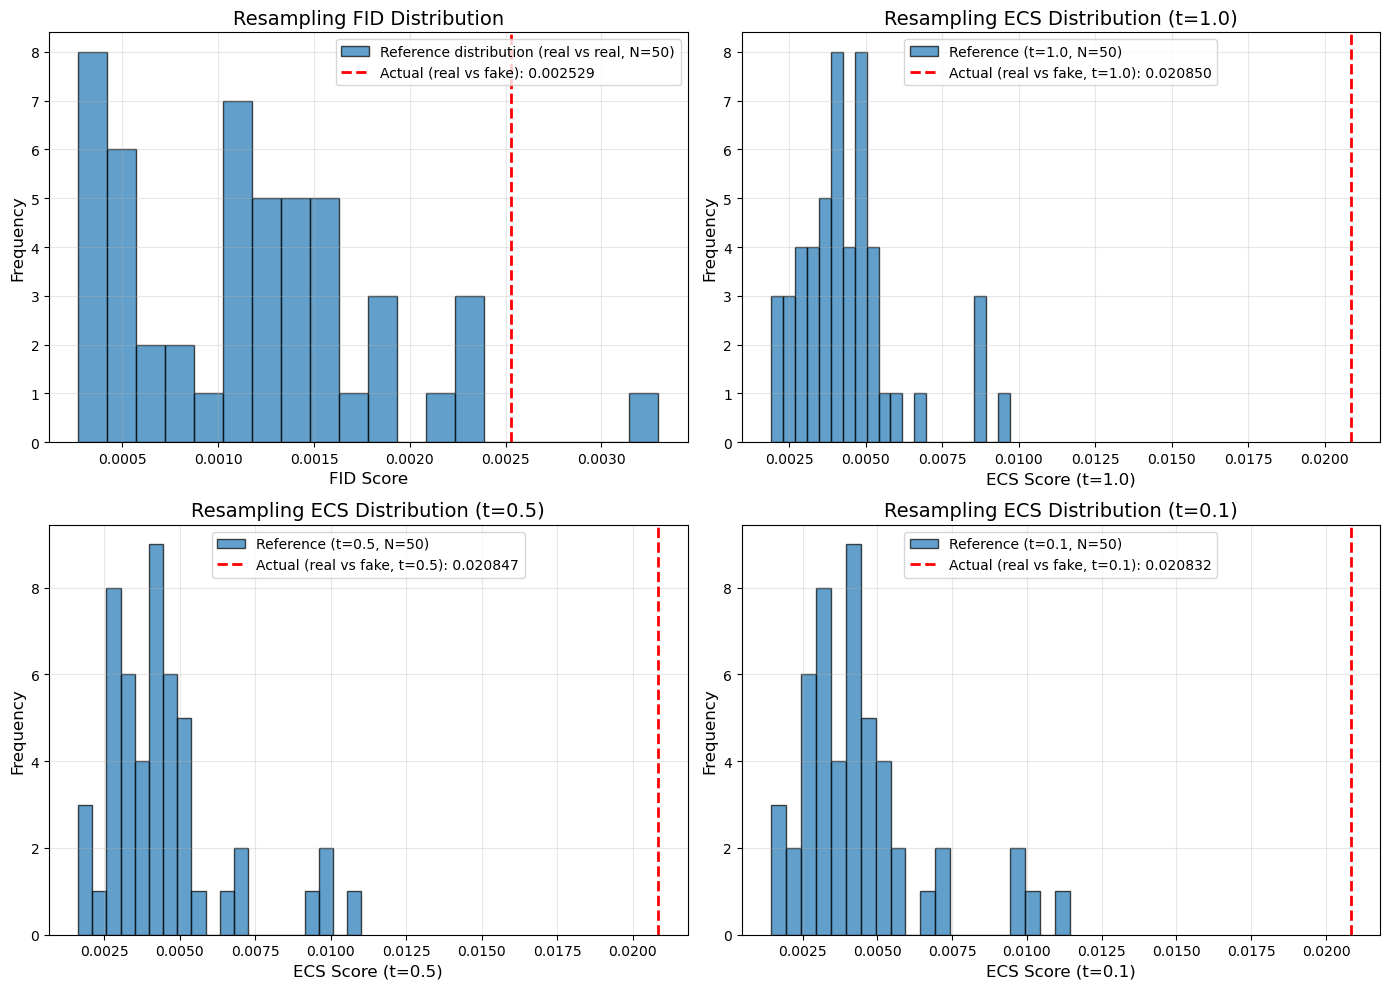


P-values (one-sided):
  FID: 0.0200 (proportion of reference FID >= actual FID)
  ECS (t=1.0): 0.0000 (proportion of reference ECS >= actual ECS)
  ECS (t=0.5): 0.0000 (proportion of reference ECS >= actual ECS)
  ECS (t=0.1): 0.0000 (proportion of reference ECS >= actual ECS)

Ratio of actual FID to median reference FID: 2.1673
Ratio of actual ECS (t=1.0) to median reference ECS (t=1.0): 5.0679
Ratio of actual ECS (t=0.5) to median reference ECS (t=0.5): 5.0018
Ratio of actual ECS (t=0.1) to median reference ECS (t=0.1): 5.0631


In [37]:
## Resampling Analysis: Real vs Real (Reference) vs Real vs Fake

# Number of resampling iterations
N = 50

# Get the number of samples
n = len(real_features)
print(f"Using n = {n} samples for comparison")

# ECS scale parameters to test
t_vals = [1.0, 0.5, 0.1]

# Compute actual FID and ECS (real vs fake)
# FID
mu_fake = torch.mean(fake_features_tensor, dim=0)
sigma_fake = torch.cov(fake_features_tensor.T)
mu_real = torch.mean(real_features_tensor, dim=0)
sigma_real = torch.cov(real_features_tensor.T)

diff = mu_real.numpy() - mu_fake.numpy()
covmean = sqrtmat(np.matmul(sigma_fake.numpy(), sigma_real.numpy()))

if np.iscomplexobj(covmean):
    covmean = covmean.real
actual_fid = np.sqrt(np.sum(diff**2) + np.trace(sigma_real.numpy() + sigma_fake.numpy() - 2 * covmean)) / n

# Compute ECS (real vs fake) for all t
actual_ecs = {}
for t in t_vals:
    characteristic_fake_actual = estimate_characteristic_function(fake_features, t)
    characteristic_real_actual = estimate_characteristic_function(real_features, t)
    difference_actual = characteristic_fake_actual - characteristic_real_actual
    norms_actual = np.abs(difference_actual)
    actual_ecs[t] = np.mean(norms_actual) / t

print(f"\nActual FID (real vs fake): {actual_fid:.6f}")
for t in t_vals:
    print(f"Actual ECS (real vs fake, t={t}): {actual_ecs[t]:.6f}")

# Resampling: resample 2n real images and compute FID and ECS for n real vs n real
print(f"\nPerforming {N} resampling iterations...")
bootstrap_fids = []
bootstrap_ecs = {t: [] for t in t_vals}

np.random.seed(42)  # For reproducibility

for i in range(N):
    if (i + 1) % 10 == 0:
        print(f"  Iteration {i + 1}/{N}")

    # Resample 2n real images with replacement
    resampled_indices = np.random.choice(n, size=2*n, replace=True)

    # Split into two groups of n
    group1_indices = resampled_indices[:n]
    group2_indices = resampled_indices[n:]

    # Get feature embeddings for each group
    group1_features = real_features_tensor[group1_indices]
    group2_features = real_features_tensor[group2_indices]

    # Compute FID (group1 vs group2)
    mu1 = torch.mean(group1_features, dim=0)
    sigma1 = torch.cov(group1_features.T)
    mu2 = torch.mean(group2_features, dim=0)
    sigma2 = torch.cov(group2_features.T)

    diff = mu1.numpy() - mu2.numpy()
    covmean = sqrtmat(np.matmul(sigma1.numpy(), sigma2.numpy()))

    if np.iscomplexobj(covmean):
        covmean = covmean.real
    bootstrap_fid = np.sqrt(np.sum(diff**2) + np.trace(sigma1.numpy() + sigma2.numpy() - 2 * covmean)) / n
    bootstrap_fids.append(bootstrap_fid)

    # Compute ECS (group1 vs group2) for all t
    for t in t_vals:
        char1 = estimate_characteristic_function(group1_features.numpy(), t)
        char2 = estimate_characteristic_function(group2_features.numpy(), t)
        difference = char1 - char2
        norms = np.abs(difference)
        bootstrap_ecs_value = np.mean(norms) / t
        bootstrap_ecs[t].append(bootstrap_ecs_value)

bootstrap_fids = np.array(bootstrap_fids)
for t in t_vals:
    bootstrap_ecs[t] = np.array(bootstrap_ecs[t])

print(f"\nResampling complete!")
print(f"FID reference distribution: mean={np.mean(bootstrap_fids):.6f}, std={np.std(bootstrap_fids):.6f}")
for t in t_vals:
    print(f"ECS reference distribution (t={t}): mean={np.mean(bootstrap_ecs[t]):.6f}, std={np.std(bootstrap_ecs[t]):.6f}")
print(f"\nActual FID (real vs fake): {actual_fid:.6f}")
for t in t_vals:
    print(f"Actual ECS (real vs fake, t={t}): {actual_ecs[t]:.6f}")

# Plot histograms
num_plots = len(t_vals) + 1
nrows = 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))

# Flatten axes for easy indexing
axes_flat = axes.flat if isinstance(axes, np.ndarray) else [axes]

# FID histogram
ax1 = axes_flat[0]
ax1.hist(bootstrap_fids, bins=20, alpha=0.7, edgecolor='black', label=f'Reference distribution (real vs real, N={N})')
ax1.axvline(actual_fid, color='red', linestyle='--', linewidth=2, label=f'Actual (real vs fake): {actual_fid:.6f}')
ax1.set_xlabel('FID Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Resampling FID Distribution', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ECS histograms for each t
for idx, t in enumerate(t_vals):
    ax = axes_flat[idx+1]
    ax.hist(bootstrap_ecs[t], bins=20, alpha=0.7, edgecolor='black', label=f'Reference (t={t}, N={N})')
    ax.axvline(actual_ecs[t], color='red', linestyle='--', linewidth=2, label=f'Actual (real vs fake, t={t}): {actual_ecs[t]:.6f}')
    ax.set_xlabel(f'ECS Score (t={t})', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Resampling ECS Distribution (t={t})', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide any unused subplots if num_plots < nrows*ncols
for i in range(num_plots, nrows*ncols):
    axes_flat[i].axis('off')

plt.tight_layout()
plt.show()

# Compute p-values (proportion of resampling values >= actual value)
fid_pvalue = np.mean(bootstrap_fids >= actual_fid)
ecs_pvalues = {t: np.mean(bootstrap_ecs[t] >= actual_ecs[t]) for t in t_vals}

print(f"\nP-values (one-sided):")
print(f"  FID: {fid_pvalue:.4f} (proportion of reference FID >= actual FID)")
for t in t_vals:
    print(f"  ECS (t={t}): {ecs_pvalues[t]:.4f} (proportion of reference ECS >= actual ECS)")

fid_median = np.median(bootstrap_fids)
fid_ratio = actual_fid / fid_median if fid_median != 0 else np.nan
print(f"\nRatio of actual FID to median reference FID: {fid_ratio:.4f}")
for t in t_vals:
    ecs_median = np.median(bootstrap_ecs[t])
    ecs_ratio = actual_ecs[t] / ecs_median if ecs_median != 0 else np.nan
    print(f"Ratio of actual ECS (t={t}) to median reference ECS (t={t}): {ecs_ratio:.4f}")



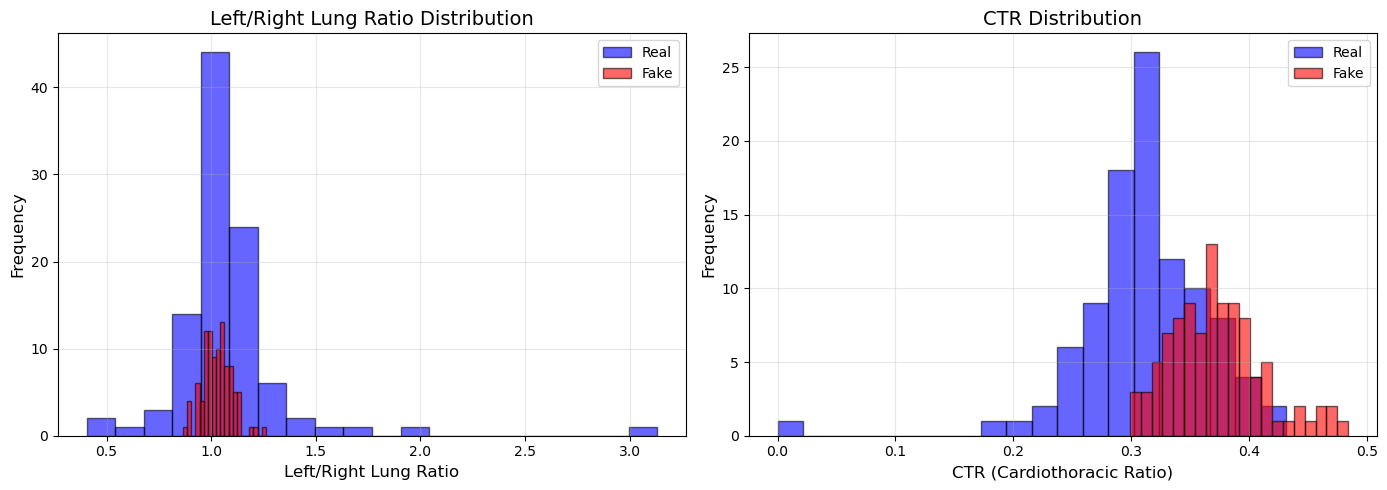

Left/Right Lung Ratio:
  Real: mean=1.0743, std=0.2906
  Fake: mean=1.0287, std=0.0685

CTR (Cardiothoracic Ratio):
  Real: mean=0.3109, std=0.0553
  Fake: mean=0.3720, std=0.0394


In [23]:
## Plot histograms for CTR and Left-Right Lung Ratio

# Feature indices:
# - Index 14: left_right_lung_ratio
# - Index 15: ctr

left_right_lung_ratio_idx = 14
ctr_idx = 15

# Extract the features
real_lung_ratio = real_features[:, left_right_lung_ratio_idx]
fake_lung_ratio = fake_features[:, left_right_lung_ratio_idx]

real_ctr = real_features[:, ctr_idx]
fake_ctr = fake_features[:, ctr_idx]

# Plot histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left-Right Lung Ratio histogram
ax1.hist(real_lung_ratio, bins=20, alpha=0.6, label='Real', color='blue', edgecolor='black')
ax1.hist(fake_lung_ratio, bins=20, alpha=0.6, label='Fake', color='red', edgecolor='black')
ax1.set_xlabel('Left/Right Lung Ratio', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Left/Right Lung Ratio Distribution', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# CTR histogram
ax2.hist(real_ctr, bins=20, alpha=0.6, label='Real', color='blue', edgecolor='black')
ax2.hist(fake_ctr, bins=20, alpha=0.6, label='Fake', color='red', edgecolor='black')
ax2.set_xlabel('CTR (Cardiothoracic Ratio)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('CTR Distribution', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Left/Right Lung Ratio:")
print(f"  Real: mean={np.mean(real_lung_ratio):.4f}, std={np.std(real_lung_ratio):.4f}")
print(f"  Fake: mean={np.mean(fake_lung_ratio):.4f}, std={np.std(fake_lung_ratio):.4f}")

print("\nCTR (Cardiothoracic Ratio):")
print(f"  Real: mean={np.mean(real_ctr):.4f}, std={np.std(real_ctr):.4f}")
print(f"  Fake: mean={np.mean(fake_ctr):.4f}, std={np.std(fake_ctr):.4f}")



Found 112120 real images
Found 100 fake images


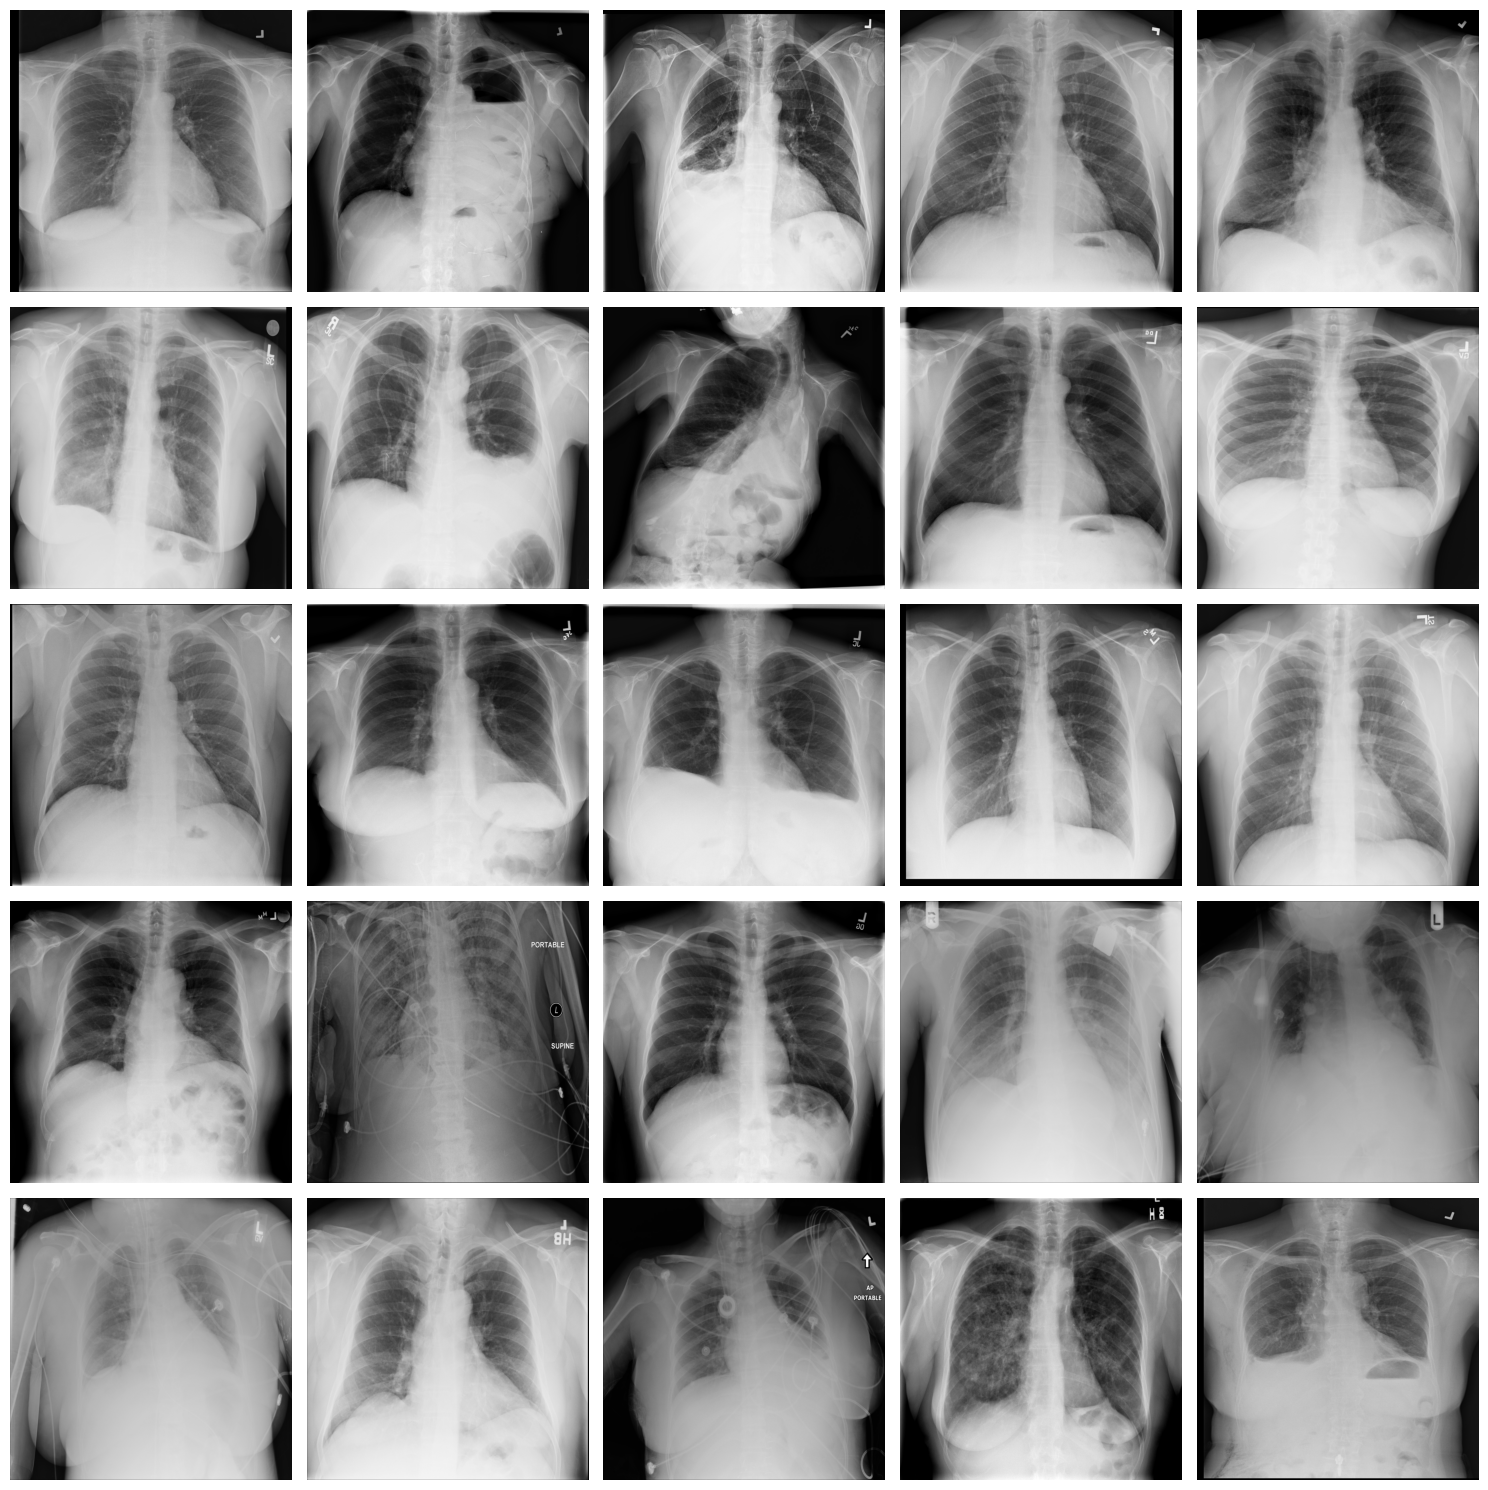

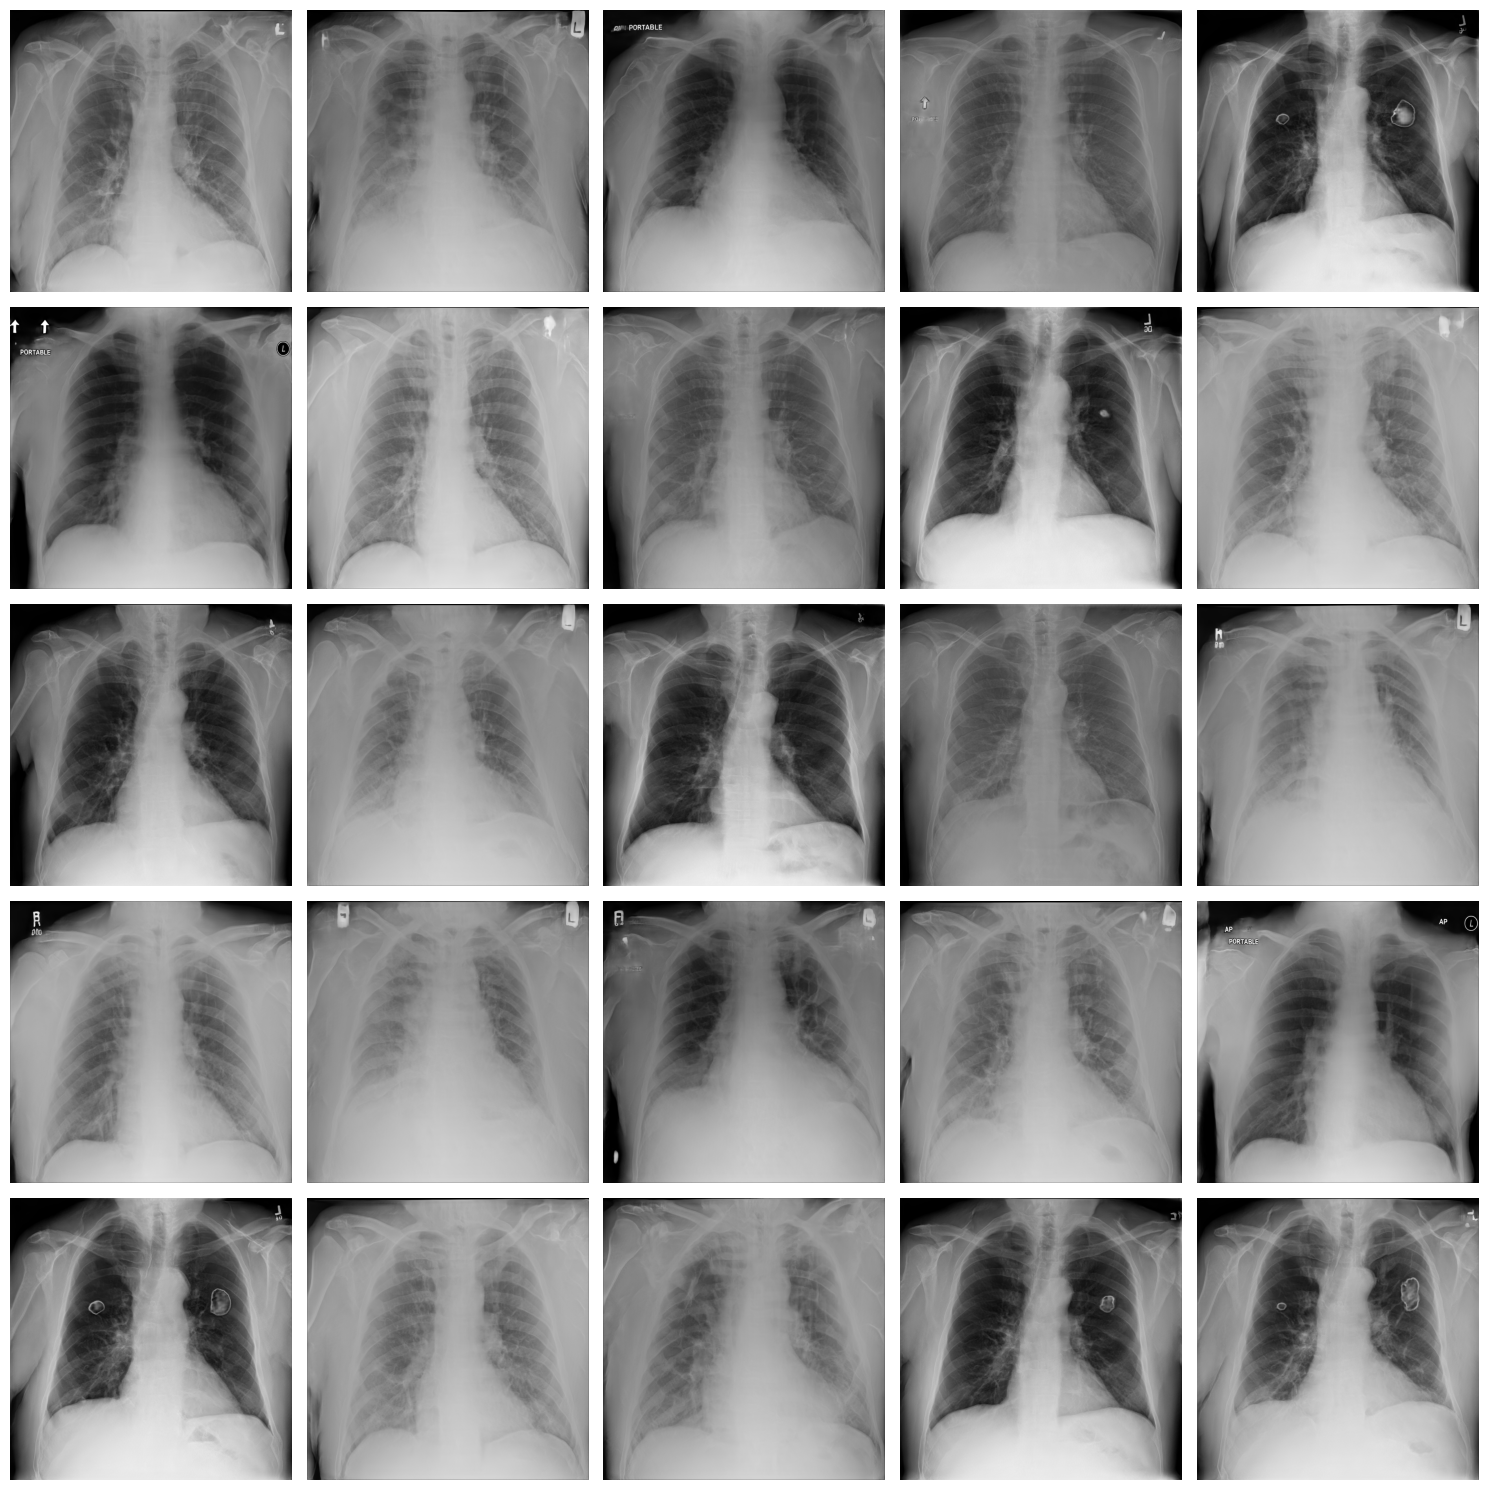

In [ ]:
## Display 25 random images from real and fake directories in 5x5 grids

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Get all images from directories
all_images_dir = 'all_images'
fake_images_dir = 'output/00020_PGGAN_CHEST_XRAY'

real_image_files = glob.glob(os.path.join(all_images_dir, '*.png'))
fake_image_files = glob.glob(os.path.join(fake_images_dir, '*.png'))

print(f"Found {len(real_image_files)} real images")
print(f"Found {len(fake_image_files)} fake images")

# Sample 25 random images from each
n_samples = 25
if len(real_image_files) < n_samples:
    print(f"Warning: Only {len(real_image_files)} real images available, using all of them")
    selected_real = real_image_files
else:
    selected_real = random.sample(real_image_files, n_samples)

if len(fake_image_files) < n_samples:
    print(f"Warning: Only {len(fake_image_files)} fake images available, using all of them")
    selected_fake = fake_image_files
else:
    selected_fake = random.sample(fake_image_files, n_samples)

# Create full 5x5 grids
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

# Real images 5x5 grid
for i in range(5):
    for j in range(5):
        idx = i * 5 + j
        if idx < len(selected_real):
            img_path = selected_real[idx]
            img = Image.open(img_path).convert('RGB')
            axes[i, j].imshow(img)
        axes[i, j].axis('off')

# plt.suptitle('25 Random Real Images', fontsize=16, y=0.995)
plt.tight_layout()
# os.makedirs("figures", exist_ok=True)
plt.savefig("figures/test1_chest_xray.png", bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(5, 5, figsize=(15, 15))

# Fake images 5x5 grid
for i in range(5):
    for j in range(5):
        idx = i * 5 + j
        if idx < len(selected_fake):
            img_path = selected_fake[idx]
            img = Image.open(img_path).convert('RGB')
            axes[i, j].imshow(img)
        axes[i, j].axis('off')

# plt.suptitle('25 Random Fake Images', fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig("figures/test2_chest_xray.png", bbox_inches='tight')
plt.show()



In [31]:
model.targets

['Left Clavicle',
 'Right Clavicle',
 'Left Scapula',
 'Right Scapula',
 'Left Lung',
 'Right Lung',
 'Left Hilus Pulmonis',
 'Right Hilus Pulmonis',
 'Heart',
 'Aorta',
 'Facies Diaphragmatica',
 'Mediastinum',
 'Weasand',
 'Spine']